In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import load_iris
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans


In [ ]:
from sklearn.datasets import make_blobs
x, y_true = make_blobs(n_samples=500, centers=4, cluster_std=0.70)

In [ ]:
df = pd.DataFrame(x, columns=['feature1', 'feature2'])
df.head(10)


,feature1,feature2
0,0.174656,9.036328
1,-4.445895,3.522293
2,-5.762880,-3.228151
3,-5.579018,-1.723271
4,2.561279,-3.147723
5,-0.832272,10.202521
6,-4.652933,3.069283
7,-4.264312,-2.002481
8,-4.683233,1.253088
9,-3.436836,2.741741


In [ ]:
df.shape

(500, 2)

In [ ]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
x_scaled = scaler.fit_transform(df)
print(x_scaled[:5])


[[ 0.77754337  1.45583184]
 [-0.66124584  0.39925341]
 [-1.07134043 -0.89424119]
 [-1.01408804 -0.60588168]
 [ 1.52071155 -0.87882976]]


In [ ]:
from sklearn.cluster import KMeans
kmeans = KMeans(n_clusters=3)
lables = kmeans.fit_predict(x_scaled)
df["Cluster"] = lables
df.head(10)

,feature1,feature2,Cluster
0,0.174656,9.036328,1
1,-4.445895,3.522293,0
2,-5.762880,-3.228151,0
3,-5.579018,-1.723271,0
4,2.561279,-3.147723,2
5,-0.832272,10.202521,1
6,-4.652933,3.069283,0
7,-4.264312,-2.002481,0
8,-4.683233,1.253088,0
9,-3.436836,2.741741,0


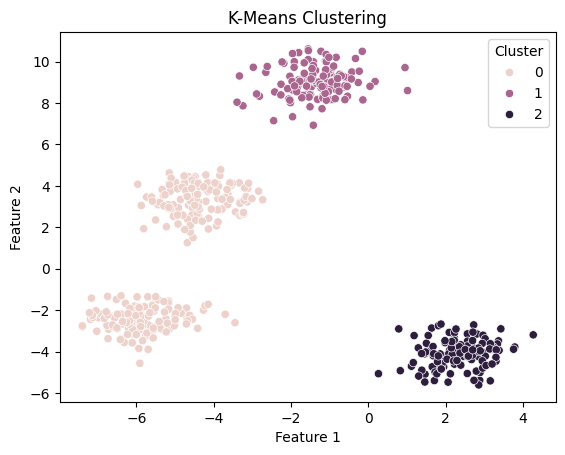

In [ ]:
import matplotlib.pyplot as plt
sns.scatterplot(x="feature1", y="feature2", hue="Cluster", data=df)
plt.title("K-Means Clustering")
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.show()

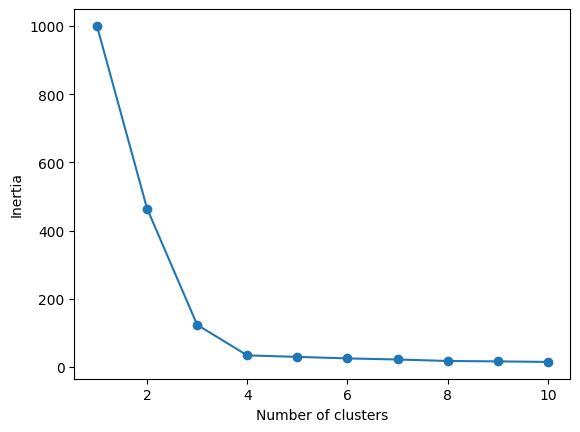

In [ ]:
errors = []
k_value = range(1, 11)
for k in k_value:
    kmeans = KMeans(n_clusters=k)
    kmeans.fit(x_scaled)
    errors.append(kmeans.inertia_)
plt.plot(k_value, errors, marker='o')
plt.xlabel('Number of clusters')
plt.ylabel('Inertia')
plt.show()

In [ ]:

kmeans = KMeans(n_clusters=4, random_state=42)
df["final_Cluster"] = kmeans.fit_predict(x_scaled)
print(df["final_Cluster"].value_counts())

final_Cluster
3    125
1    125
2    125
0    125
Name: count, dtype: int64


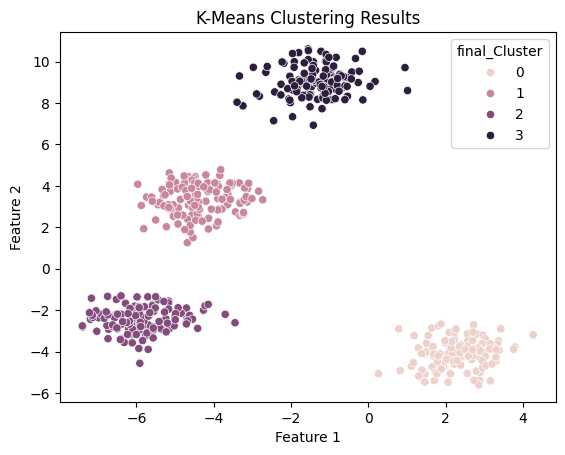

In [ ]:
sns.scatterplot(x="feature1", y="feature2", hue="final_Cluster", data=df)
plt.title("K-Means Clustering Results")
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.show()


## Iris


In [ ]:
from sklearn.datasets import load_iris
iris=load_iris()

In [ ]:
df=pd.DataFrame(iris.data, columns=iris.feature_names)
scaler=StandardScaler()
x_scaled=scaler.fit_transform(df)
kmeans=KMeans(n_clusters=3, random_state=42)
df["Cluster"]=kmeans.fit_predict(x_scaled)
print(df["Cluster"].value_counts())

Cluster
0    96
1    33
2    21
Name: count, dtype: int64


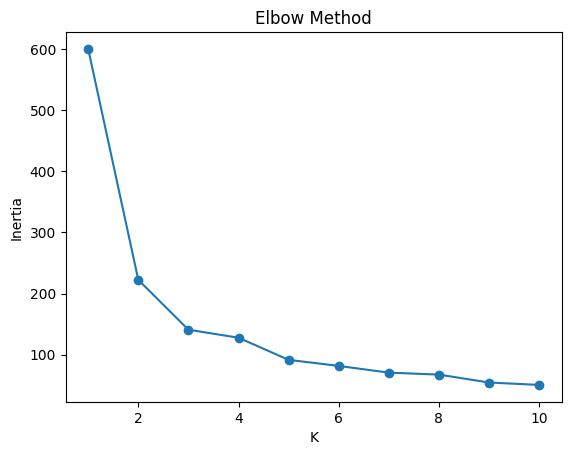

In [ ]:
errors = []
k_value = range(1, 11)
for k in k_value:
    kmeans = KMeans(n_clusters=k)
    kmeans.fit(x_scaled)
    errors.append(kmeans.inertia_)

plt.plot(k_value, errors, marker='o')
plt.xlabel('K')
plt.ylabel('Inertia')
plt.title('Elbow Method')
plt.show()

In [ ]:
kmeans = KMeans(n_clusters=3, random_state=42)
df["final_Cluster"] = kmeans.fit_predict(x_scaled)
print(df["final_Cluster"].value_counts())


final_Cluster
0    96
1    33
2    21
Name: count, dtype: int64


   sepal length (cm)  sepal width (cm)  petal length (cm)  petal width (cm)
0                5.1               3.5                1.4               0.2
1                4.9               3.0                1.4               0.2
2                4.7               3.2                1.3               0.2
3                4.6               3.1                1.5               0.2
4                5.0               3.6                1.4               0.2
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 4 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   sepal length (cm)  150 non-null    float64
 1   sepal width (cm)   150 non-null    float64
 2   petal length (cm)  150 non-null    float64
 3   petal width (cm)   150 non-null    float64
dtypes: float64(4)
memory usage: 4.8 KB
None
       sepal length (cm)  sepal width (cm)  petal length (cm)  \
count         150.000000        150.000000

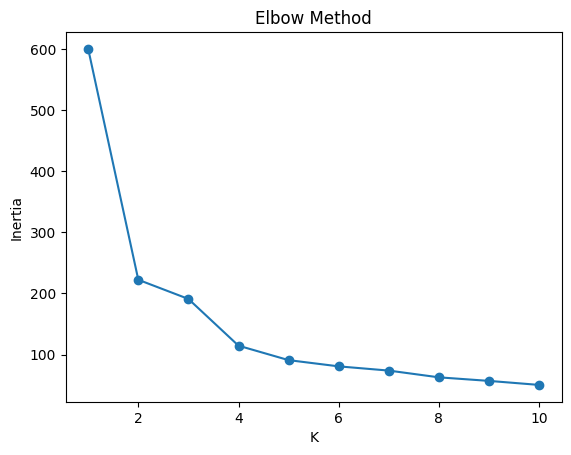

Cluster
0    96
1    33
2    21
Name: count, dtype: int64


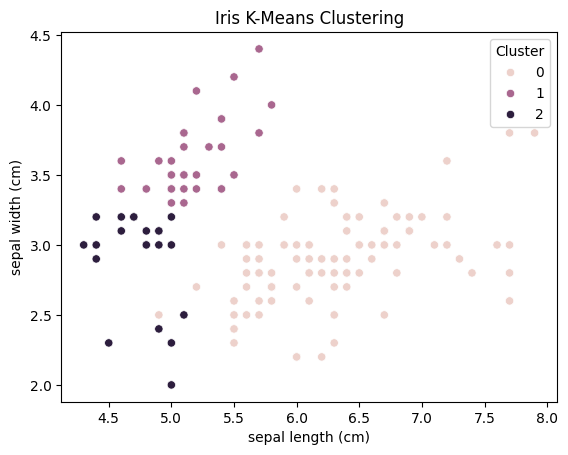

In [ ]:

# Load dataset
iris = load_iris()

df = pd.DataFrame(iris.data,columns=iris.feature_names)

print(df.head())
print(df.info())
print(df.describe())

# Select numerical features
X = df

#Scalling
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Elbow Method
errors = []
k_value = range(1, 11)
for k in k_value:
    kmeans = KMeans(n_clusters=k)
    kmeans.fit(x_scaled)
    errors.append(kmeans.inertia_)

plt.plot(k_value, errors, marker='o')
plt.xlabel('K')
plt.ylabel('Inertia')
plt.title('Elbow Method')
plt.show()

# Final Model
kmeans = KMeans(n_clusters=3, random_state=42)
df["Cluster"] = kmeans.fit_predict(x_scaled)
print(df["Cluster"].value_counts())

# Visualization
sns.scatterplot(data=df, x="sepal length (cm)", y="sepal width (cm)", hue="Cluster")
plt.title("Iris K-Means Clustering")
plt.show()
